<a href="https://colab.research.google.com/github/Kartikiscalm/IML-LAB-/blob/labs/Lab3_Logistic_Regression_Binary_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3: Logistic Regression & Binary Classification

**Course:** Introduction to Machine Learning

---

### How to use this notebook

* Read every **Markdown** cell before running the **Code** cell below it.
* Run cells **in order** (top to bottom). Later cells depend on variables created earlier.
* Cells marked **✍️ EXERCISE** or containing `TODO` markers are where *you* write code.
* These exercises are **woven throughout the notebook** — you must complete each one before moving on,
  because later cells may depend on your work.
* Answer every **Question** in the text cell provided. Your reasoning matters as much as your code.


> In Colab: run a cell with `Shift + Enter`. If something breaks, use *Runtime → Restart and run all*.

---

### Learning Objectives

By the end of this lab you should be able to:

1. **Explain what binary classification is** and how it differs from regression.
2. **Explain the intuition behind logistic regression** and why plain linear regression is a poor fit for classification.
3. **Describe the sigmoid (logistic) function** and why its output can be read as a probability.
4. **Distinguish between a predicted probability, a decision threshold, and a predicted class label.**
5. **Train and evaluate a logistic regression model** with scikit-learn on both synthetic and real data.
6. **Interpret the confusion matrix and accuracy**, understand the four types of outcomes (TP, TN, FP, FN), and argue which type of error matters more for a given problem.

---

### Prerequisites (you should already know these)

Python basics, NumPy, Pandas, Matplotlib, basic probability, linear regression, train/test split, and the general idea of supervised learning.

**IMPORTANT Submission Information**

---

Create a copy of this notebook before writing your code.
The ToDo cells must be completed and submitted via [GC Lab 3 Submission](https://classroom.google.com/c/ODU0NzY0NjAxMzk5/a/ODc0NzEzNDI2NDE2/details). This submission is important because in absence of this your assignment-1 won't be evaluated.

### Setup

Run this cell first. Everything below depends on it.

All libraries used here are pre-installed in Google Colab, so there is nothing to download and no files to upload.

In [ ]:
# --- Core libraries -----------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- A fixed random seed makes your results reproducible ----------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- Nicer default plots ------------------------------------------------
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# --- Show all DataFrame columns when printing ---------------------------
pd.set_option("display.width", 120)

print("Setup complete.")
print("NumPy:", np.__version__, "| Pandas:", pd.__version__)

Setup complete.
NumPy: 2.0.2 | Pandas: 2.2.3


---
# PART A — CONCEPTUAL INTRODUCTION
---

## 2. What is Classification?

In **supervised learning** we are given examples of inputs together with the correct answers, and we
want the computer to learn the mapping from input to answer.

* If the answer is a **number on a continuous scale** → that is **regression**.
  *How much will this house sell for?* → `₹ 84,50,000`
* If the answer is a **category / label** → that is **classification**.
  *Is this email spam?* → `spam` or `not spam`

### Binary vs. Multiclass classification

| Type | Number of possible labels | Example |
|---|---|---|
| **Binary** | Exactly 2 | Spam / Not spam |
| **Multiclass** | 3 or more | Handwritten digit: 0,1,2,…,9 |

This lab is entirely about **binary classification**. By convention we encode the two classes as
**0** (the "negative" class) and **1** (the "positive" class).

> ⚠️ "Positive" does **not** mean "good". It just means *the class we chose to call 1* — usually the
> event we are trying to detect (disease present, fraud, churn). Keeping this straight will matter a lot
> when we get to the confusion matrix.

### Everyday binary classification problems

| Problem | Class 0 | Class 1 |
|---|---|---|
| Email filtering | not spam | spam |
| Medical screening | no disease | disease |
| Exam outcome | fail | pass |
| Credit card transaction | legitimate | fraud |
| Subscription business | customer stays | customer churns |

### Regression vs. Classification at a glance

| Regression | Classification |
|---|---|
| Predicts a continuous value | Predicts a class |
| Example: house price | Example: spam / not spam |
| Typical output: `23.5` | Typical output: `0` or `1` |
| Error measured with e.g. RMSE | Error measured with e.g. accuracy |
| "How much?" / "How many?" | "Which one?" / "Is it?" |

## 3. Why Not Just Use Linear Regression?

Our labels are numbers (`0` and `1`), so a tempting idea is: *just fit a straight line*

$$\hat{y} = \beta_0 + \beta_1 x$$

and then round the result. Let's actually try it and see what goes wrong.

The cell below fits a straight line to a tiny dataset: **hours studied** → **passed (1) / failed (0)**.

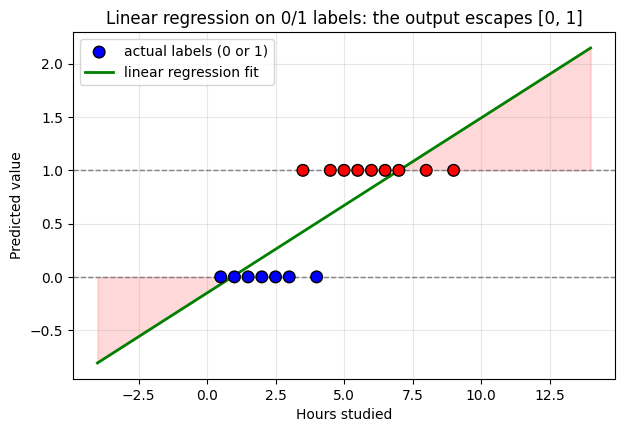

Prediction at  -3 hours : -0.643
Prediction at  13 hours : 1.984


In [ ]:
from sklearn.linear_model import LinearRegression

# A tiny dataset: hours studied -> did the student pass? (0 = fail, 1 = pass)
hours = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0,
                  5.5, 6.0, 6.5, 7.0, 8.0, 9.0]).reshape(-1, 1)
passed = np.array([0,   0,   0,   0,   0,   0,   1,   0,   1,   1,
                   1,   1,   1,   1,   1,   1])

# Fit an ordinary linear regression to the 0/1 labels
linreg = LinearRegression()
linreg.fit(hours, passed)

# Predict over a WIDE range of hours, including values outside the training range
grid = np.linspace(-4, 14, 200).reshape(-1, 1)
line = linreg.predict(grid)

plt.scatter(hours, passed, c=passed, cmap="bwr", edgecolor="k", s=70, zorder=3,
            label="actual labels (0 or 1)")
plt.plot(grid, line, color="green", lw=2, label="linear regression fit")
plt.axhline(0, color="gray", ls="--", lw=1)
plt.axhline(1, color="gray", ls="--", lw=1)
plt.fill_between(grid.ravel(), 1, line, where=(line > 1), color="red", alpha=0.15)
plt.fill_between(grid.ravel(), 0, line, where=(line < 0), color="red", alpha=0.15)
plt.title("Linear regression on 0/1 labels: the output escapes [0, 1]")
plt.xlabel("Hours studied")
plt.ylabel("Predicted value")
plt.legend()
plt.show()

print("Prediction at  -3 hours :", round(float(linreg.predict([[-3]])[0]), 3))
print("Prediction at  13 hours :", round(float(linreg.predict([[13]])[0]), 3))

### What just went wrong?

Look at the shaded red regions and the two printed numbers:

1. **The predictions leave the interval [0, 1].** A "probability" of `-0.28` or `1.35` is meaningless.
2. **A straight line has no notion of saturation.** Studying 20 hours instead of 10 cannot make you
   "more than certain" to pass — but a line keeps climbing forever.
3. **The line is very sensitive to extreme points.** One student who studied 40 hours would tilt the
   whole line and change predictions for everyone else.

### What we actually want

A function that:

* accepts **any real number** as input (the linear part $\beta_0 + \beta_1 x$ can be anything), and
* returns a value **squashed into the range $[0, 1]$**, so we can read it as a probability.

That function is the **sigmoid**.

### 🧠 Question 3.1 — Linear regression for classification

> **(a)** Looking at the plot above, what is the predicted value at -3 hours? Is that a meaningful probability? Why or why not?
>
> **(b)** If we round the linear regression output to 0 or 1 using a threshold of 0.5, would that fix all the problems? Think about what happens to the decision boundary and whether the model can still capture non-linear patterns.
>
> **(c)** A classmate argues: "We could just clip the output to [0, 1] instead of using a sigmoid." What would be the downside of clipping compared to the smooth sigmoid curve? Think about what happens to the gradient during training.

✍️ **Your answers:**

(a) ...
(b) ...
(c) ...

## 4. The Sigmoid (Logistic) Function

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Read it as a *squashing* function: whatever real number $z$ you feed in, you get a number strictly between 0 and 1 out.

Key behaviour:

| Input $z$ | Output $\sigma(z)$ | Interpretation |
|---|---|---|
| $z \to +\infty$ | $\to 1$ | almost certainly class 1 |
| $z = 0$ | exactly $0.5$ | completely undecided |
| $z \to -\infty$ | $\to 0$ | almost certainly class 0 |

Let's implement it and plot it — the code is only a few lines.

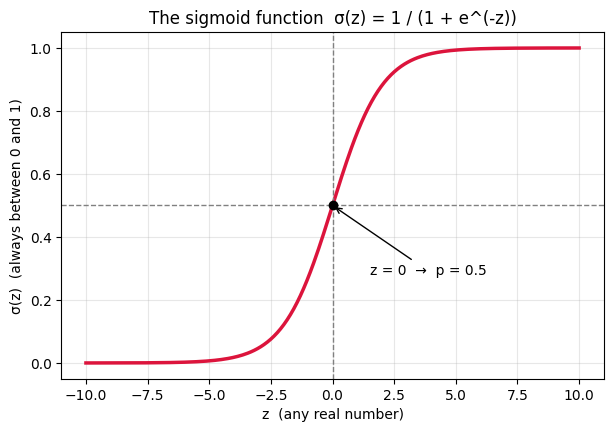

sigmoid( -6) = 0.0025
sigmoid( -2) = 0.1192
sigmoid( -1) = 0.2689
sigmoid(  0) = 0.5000
sigmoid(  1) = 0.7311
sigmoid(  2) = 0.8808
sigmoid(  6) = 0.9975


In [ ]:
def sigmoid(z):
    # Squash any real number (or NumPy array) into the range (0, 1).
    # sigma(z) = 1 / (1 + e^(-z))
    return 1 / (1 + np.exp(-z))


# Plot the sigmoid over a range of z values
z = np.linspace(-10, 10, 300)
p = sigmoid(z)

plt.plot(z, p, color="crimson", lw=2.5)
plt.axhline(0.5, color="gray", ls="--", lw=1)
plt.axvline(0.0, color="gray", ls="--", lw=1)
plt.scatter([0], [0.5], color="black", zorder=5)
plt.annotate("z = 0  →  p = 0.5", xy=(0, 0.5), xytext=(1.5, 0.28),
             arrowprops=dict(arrowstyle="->"))
plt.ylim(-0.05, 1.05)
plt.title("The sigmoid function  σ(z) = 1 / (1 + e^(-z))")
plt.xlabel("z  (any real number)")
plt.ylabel("σ(z)  (always between 0 and 1)")
plt.show()

# Check a few specific values
for value in [-6, -2, -1, 0, 1, 2, 6]:
    print(f"sigmoid({value:>3}) = {sigmoid(value):.4f}")

### Reading the plot

* The curve **never touches 0 or 1** — it only approaches them. So the model is never 100% certain.
* The curve is **steepest around $z = 0$**: small changes in $z$ near the middle change the probability a lot,
  while far out on either side the probability barely moves.
* $\sigma(z)$ is **symmetric**: $\sigma(-z) = 1 - \sigma(z)$. (Check it with the printed values above:
  `sigmoid(-2)` and `sigmoid(2)` should add up to 1.)

### ✍️ EXERCISE 1 — Implement and Explore the Sigmoid

You just saw the sigmoid function. Now it is your turn to implement it from scratch and verify
its key properties. **Complete the code cell below before moving on** — later sections depend on
your `my_sigmoid` function working correctly.

Consider these values:

$$z = [-5,\ -2,\ 0,\ 2,\ 5]$$

**Part (a) — By hand:** Using $\sigma(z) = \dfrac{1}{1 + e^{-z}}$ and $e \approx 2.718$, compute
$\sigma(z)$ for **at least two** of the values above. Show your working in the answer cell.

**Part (b) — In Python:** Complete the code cell below.

In [ ]:
# ===================== EXERCISE 1 =======================

z_values = np.array([-5, -2, 0, 2, 5])

# TODO 1: write a function that computes the sigmoid of its input.
#         It must work on a NumPy array, not just a single number.
# def my_sigmoid(z):
#     return ...

# TODO 2: apply your function to z_values and store the result
# probabilities = ...

# TODO 3: print each z next to its sigmoid value, rounded to 4 decimals.
#         Expected shape of the output (your numbers will fill the blanks):
#             z = -5  ->  sigma(z) = 0.____
#             z = -2  ->  sigma(z) = 0.____
#             ...
# for zi, pi in zip(z_values, probabilities):
#     print(...)

# TODO 4 (check): verify numerically that sigma(-z) == 1 - sigma(z) for these values.
#                 Hint: np.allclose(...)
# print("Symmetry holds:", ...)

### Part (c) — Questions

> **1.** What happens to $\sigma(z)$ as $z$ increases? Does it ever reach exactly 1? Explain using the formula.
> **2.** Which value of $z$ produces a probability of exactly 0.5? Show algebraically *why* that is the value.
> **3.** The difference $\sigma(2) - \sigma(0)$ is much larger than $\sigma(7) - \sigma(5)$, even though both
> gaps in $z$ are the same size. Why? What does this mean about how sensitive a logistic regression model is
> to changes in its inputs for confident vs. uncertain samples?

✍️ **Your answers:**

1. ...
2. ...
3. ...

### 🧠 Question 4.1 — Sigmoid properties

> **(a)** Using the printed values above, verify that $\sigma(-2) + \sigma(2) = 1$. Why is this symmetry property useful?
>
> **(b)** At which value of $z$ is the sigmoid changing *most rapidly*? What does this mean in terms of the model's sensitivity to small changes in input?
>
> **(c)** Suppose a logistic regression model for spam detection has $\beta_0 = -3$ and $\beta_1 = 0.8$ (for the number of exclamation marks). An email has 5 exclamation marks. Compute $z$ and then $\sigma(z)$ by hand (you may use a calculator for $e^{-z}$). Would this email be classified as spam using a 0.5 threshold?

✍️ **Your answers:**

(a) ...
(b) ...
(c) ...


## 5. Logistic Regression, Step by Step

Logistic regression is just **linear regression followed by a sigmoid**, plus a rule for turning the
resulting probability into a label.

**Step 1 — Compute a linear score $z$** (this is the part that "learns"):

$$z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n$$

**Step 2 — Squash it into a probability:**

$$p = \sigma(z) = \frac{1}{1 + e^{-z}}$$

Here $p$ is the model's estimate of $P(y = 1 \mid x)$ — "the probability that this example belongs to class 1".

**Step 3 — Turn the probability into a class label** using a threshold (default $0.5$):

$$\hat{y} = \begin{cases} 1 & \text{if } p \ge 0.5 \\ 0 & \text{if } p < 0.5 \end{cases}$$

---

### Three things that are *not* the same

This distinction is the single most common source of confusion in this lab. Keep it straight:

| Term | Symbol | Example value | What it is |
|---|---|---|---|
| **Linear score** | $z$ | `-1.7` | any real number; not interpretable on its own |
| **Predicted probability** | $p$ | `0.154` | a number in $(0,1)$; `model.predict_proba()` |
| **Predicted class label** | $\hat{y}$ | `0` | the final 0/1 decision; `model.predict()` |

### So why is it called "regression"?

Because the *learning* happens in the linear part. The model fits real-valued coefficients
$\beta_0, \beta_1, \dots$ to a linear expression — exactly like linear regression. Historically it is a
regression on the **log-odds**:

$$\log\!\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 x_1 + \dots + \beta_n x_n$$

The left-hand side (called the *logit*) is a continuous quantity being predicted by a linear model — hence
"regression". But because we finish by thresholding $p$, logistic regression is used almost exclusively as a
**classifier**. The name is a historical accident; don't let it mislead you.

### 🧠 Question 5.1 — Logistic regression components

> **(a)** Fill in the blanks: Logistic regression first computes a ______ score $z$, then applies the ______ function to get a ______, and finally applies a ______ to produce a class label.
>
> **(b)** A model has coefficients $\beta_0 = -1.5$, $\beta_1 = 0.4$, $\beta_2 = 0.6$. For a sample with $x_1 = 3$ and $x_2 = 2$, compute:
> - The linear score $z$
> - The probability $p = \sigma(z)$ (use the sigmoid function or your calculator)
> - The predicted class using threshold 0.5
>
> **(c)** The name "logistic regression" is often confusing for students. Explain in one sentence why it is called "regression" despite being used for classification.

✍️ **Your answers:**

(a) ...
(b) ...
(c) ...

---
# PART B — FIRST HANDS-ON EXAMPLE
---

## 6. A Simple Binary Classification Dataset

We will generate a small synthetic dataset of students. Two features:

* `hours_studied` — hours spent preparing for the exam
* `attendance` — percentage of classes attended

Target:

* `passed` — **0 = Fail**, **1 = Pass**

Synthetic data is useful for teaching because *we* control the underlying pattern, so we know what the
model *should* discover.

In [ ]:
# ---- Generate a synthetic student dataset -------------------------------
rng = np.random.default_rng(RANDOM_STATE)   # reproducible random generator
n = 120

hours_studied = rng.uniform(0, 10, n)        # 0 to 10 hours
attendance    = rng.uniform(40, 100, n)      # 40% to 100% attendance

# The TRUE hidden rule (students do not get to see this in real life!):
# a linear score, pushed through a sigmoid, then sampled as a coin flip.
true_z = -8.0 + 0.9 * hours_studied + 0.07 * attendance
true_p = 1 / (1 + np.exp(-true_z))
passed = rng.binomial(1, true_p)             # 0 = Fail, 1 = Pass

students = pd.DataFrame({
    "hours_studied": hours_studied.round(2),
    "attendance":    attendance.round(1),
    "passed":        passed
})

print("Shape:", students.shape)
students.head(10)

Shape: (120, 3)


,hours_studied,attendance,passed
0,7.74,75.0,1
1,4.39,79.0,1
2,8.59,45.1,1
3,6.97,64.9,1
4,0.94,42.5,0
5,9.76,69.6,1
6,7.61,59.8,1
7,7.86,48.7,1
8,1.28,46.2,0
9,4.50,75.3,1


In [ ]:
# Summary statistics and class balance
display(students.describe().round(2))

print("\nClass distribution:")
print(students["passed"].value_counts().sort_index())
print("\nAverage feature value per class:")
display(students.groupby("passed")[["hours_studied", "attendance"]].mean().round(2))

,hours_studied,attendance,passed
count,120.00,120.00,120.00
mean,4.99,69.25,0.68
std,2.74,18.07,0.47
min,0.07,40.80,0.00
25%,2.70,51.95,0.00
50%,4.70,69.50,1.00
75%,7.28,85.20,1.00
max,9.76,99.50,1.00



Class distribution:
passed
0    39
1    81
Name: count, dtype: int64

Average feature value per class:


,hours_studied,attendance
passed,,
0,2.37,58.99
1,6.25,74.19


## 7. Visualizing the Dataset

A scatter plot of the two features, with **colour and marker shape** indicating the class, tells us
immediately whether the classes are separable.

### ✍️ EXERCISE 2 — Plot the Data

Instead of giving you the scatter plot, create it yourself. **Complete the code cell below.**
This is an essential data-science skill: always visualize before modelling.

/tmp/ipykernel_589/955025646.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


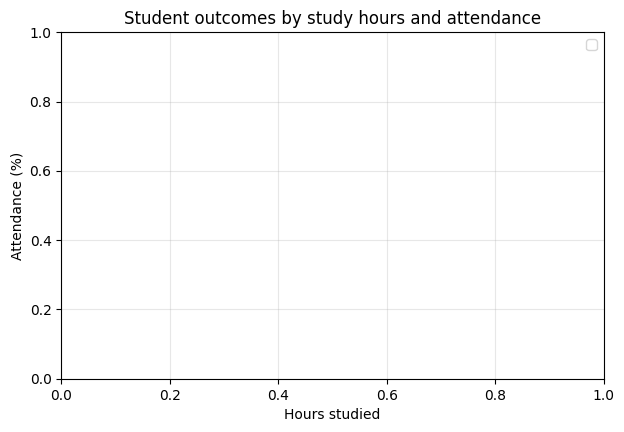

In [ ]:
# ===================== EXERCISE 2 — SCATTER PLOT =====================

# The DataFrame `students` is already loaded with columns:
#   "hours_studied", "attendance", "passed"

# TODO 1: separate the data into two groups:
#         `fail` = rows where passed == 0
#         `pas`  = rows where passed == 1
# fail = students[...]
# pas  = students[...]

# TODO 2: create a scatter plot with:
#         - Fail students as blue circles (marker='o', c='tab:blue')
#         - Pass students as red triangles (marker='^', c='tab:red')
#         - x-axis = hours_studied, y-axis = attendance
#         - axis labels, a title, and a legend
#         Hint: use plt.scatter() twice, once for each group.

plt.xlabel("Hours studied")
plt.ylabel("Attendance (%)")
plt.title("Student outcomes by study hours and attendance")
plt.legend()
plt.show()

### What the picture should tell you

Once your plot is working, you should observe:

* The two classes occupy **different regions** of the plane: fails toward the bottom-left, passes toward
  the top-right. So the features really do carry information about the outcome.
* The regions **overlap** in the middle. There is no straight line that separates them perfectly — some
  students who studied a lot still failed. This is normal and expected: real outcomes are noisy.
* Because the boundary between the regions looks roughly **straight**, a linear model like logistic
  regression is a sensible choice here.

> A classifier that gets 100% accuracy on data like this would be suspicious, not impressive.

### 🧠 Question 7.1 — Reading scatter plots


> **(a)** Are there any students who studied many hours AND had high attendance but still failed? What might explain such cases in a real-world scenario?
>
> **(b)** Based on the scatter plot, would you expect a logistic regression model to achieve 100% accuracy on this data? Why or why not?

✍️ **Your answers:**

(a) ...
(b) ...

## 8. Train/Test Split

We never judge a model on the data it learned from — it has already seen the answers. So we split:

* **Training set** — used to *learn* the coefficients $\beta$.
* **Test set** — held back, used *once* to estimate how well the model **generalises** to data it has never seen.

Two details worth noticing in the code:

* `random_state=42` makes the split reproducible, so your results match your classmates'.
* `stratify=y` keeps the **class proportions** the same in both sets. Without it, a random split could
  accidentally put most of the "Pass" students in the test set.

### ✍️ EXERCISE 3 — Train/Test Split

Apply what you just read. **Complete the code cell below** to split the student data.
The rest of the notebook uses the variables you create here (`X_train`, `X_test`, etc.), so
this cell **must** work before you can continue.

In [ ]:
# ===================== EXERCISE 3 — TRAIN/TEST SPLIT =====================
from sklearn.model_selection import train_test_split

# TODO 1: build the feature matrix X (hours_studied and attendance) and the label vector y (passed)
#         X should be a NumPy array of shape (n, 2). y should be shape (n,).
# X = students[[...]].values
# y = students[...].values

# TODO 2: split into training and test sets.
#         Use: test_size=0.25, random_state=RANDOM_STATE, stratify=y
# X_train, X_test, y_train, y_test = train_test_split(...)

# TODO 3: print the number of samples in each set and the class balance.
#         Hint: np.bincount(y_train) counts occurrences of 0 and 1.
# print(f"Training set: {X_train.shape[0]} samples")
# print(f"Test set    : {X_test.shape[0]} samples")
# print(f"Class balance in training set: {np.bincount(y_train)}")
# print(f"Class balance in test set    : {np.bincount(y_test)}")

Training set: 90 samples
Test set    : 30 samples
Class balance in training set: [29 61]  (class 0, class 1)
Class balance in test set    : [10 20]  (class 0, class 1)


### 🧠 Question 8.1 — Train/test split decisions

> **(a)** We used `test_size=0.25`. What are the trade-offs of using a larger test set (e.g. 0.5) versus a
> smaller one (e.g. 0.1)? Think about both the training quality and the reliability of the test score.
>
> **(b)** We passed `stratify=y`. Suppose the dataset had 80 Passes and 40 Fails. Without stratification,
> what is the worst-case scenario for the test set's class composition? Why would that be a problem?
>
> **(c)** A classmate says: "I split the data, trained the model, got 60% accuracy, so I tried a different
> `random_state`, got 85%, and reported that." What is fundamentally wrong with this approach?

✍️ **Your answers:**

(a) ...
(b) ...
(c) ...


## 9. Implementing Logistic Regression model


In [ ]:
class LogisticRegressionScratch:
    # A from-scratch logistic regression to understand the internals.
    # Includes automatic feature scaling so gradient descent converges
    # even when features are on very different scales (e.g. hours 0-10
    # vs attendance 40-100).

    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None

    # Sigmoid function
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    # Internal helper: standardise features
    def _scale(self, X):
        return (X - self._mean) / self._std

    # Train the model
    def fit(self, X, y):

        # ---- Feature scaling (learn mean/std from training data) --------
        self._mean = X.mean(axis=0)
        self._std  = X.std(axis=0)
        self._std[self._std == 0] = 1  # guard against constant columns
        X_scaled = self._scale(X)

        n_samples, n_features = X_scaled.shape

        # Initialize parameters
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Gradient Descent
        for _ in range(self.n_iterations):

            # 1. Linear combination
            z = np.dot(X_scaled, self.weights) + self.bias

            # 2. Convert to probability
            y_pred = self.sigmoid(z)

            # 3. Calculate gradients
            dw = (1 / n_samples) * np.dot(X_scaled.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            # 4. Update weights and bias
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

        # Convert learned weights from scaled space back to original feature space
        # so the reported coefficients are directly interpretable.
        #   z = w·x_scaled + b = w·((x - μ)/σ) + b = (w/σ)·x + (b - w·μ/σ)
        self.coef_ = (self.weights / self._std).reshape(1, -1)          # shape (1, n_features)
        self.intercept_ = np.array([self.bias - np.sum(self.weights * self._mean / self._std)])

    # Predict probabilities — returns shape (n_samples, 2), same as sklearn
    def predict_proba(self, X):

        X_scaled = self._scale(X)
        z = np.dot(X_scaled, self.weights) + self.bias

        p_class_1 = self.sigmoid(z)
        p_class_0 = 1 - p_class_1

        return np.column_stack((p_class_0, p_class_1))

    # Predict class labels — returns a 1-D array of 0s and 1s
    def predict(self, X):

        proba = self.predict_proba(X)[:, 1]   # use ONLY the class-1 column

        return (proba >= 0.5).astype(int)

    # Accuracy helper so model.score() works like sklearn
    def score(self, X, y):
        return np.mean(self.predict(X) == y)


In [ ]:
model = LogisticRegressionScratch(
    learning_rate=0.01,
    n_iterations=1000
)

model.fit(X_train, y_train)

print("Intercept  (β₀)      :", model.intercept_.round(3))
print("Coefficients (β₁, β₂):", model.coef_.round(3))

NameError: name 'LogisticRegressionScratch' is not defined

### What did the model learn?

* **`Intercept`** is $\beta_0$ — the linear score when every feature is 0. It shifts the whole
  sigmoid left or right.
* **`Coefficients`** holds $\beta_1$ (hours studied) and $\beta_2$ (attendance). The **sign** tells you the
  direction of the effect: a positive coefficient means *more of this feature pushes the prediction toward class 1*.

So the fitted model computes:

$$z = \beta_0 + \beta_1 \cdot \texttt{hours_studied} + \beta_2 \cdot \texttt{attendance}, \qquad p = \sigma(z)$$


### 🧠 Question 9.1 — Model coefficients

> **(a)** Both coefficients $\beta_1$ and $\beta_2$ are positive. What does that tell you about the relationship between each feature and the probability of passing?

>
> **(b)** What does the intercept ($\beta_0$) represent? For this model the intercept is a negative number — what does that tell you about a student who studies 0 hours and has 0% attendance?

✍️ **Your answers:**

(a) ...
(b) ...

In [ ]:
# ---- Predicted CLASSES vs predicted PROBABILITIES -----------------------
y_pred  = model.predict(X_test)             # 0 / 1 labels
y_proba = model.predict_proba(X_test)       # two columns of probabilities

print("predict()       ->", y_pred[:10])
print("predict_proba() -> shape", y_proba.shape, "(one row per sample, one column per class)\n")

comparison = pd.DataFrame({
    "hours":       X_test[:, 0].round(2),
    "attendance":  X_test[:, 1].round(1),
    "P(class 0)":  y_proba[:, 0].round(3),
    "P(class 1)":  y_proba[:, 1].round(3),
    "predicted":   y_pred,
    "actual":      y_test
})
comparison.head(10)

predict()       -> [1 1 1 1 0 0 0 1 1 0]
predict_proba() -> shape (30, 2) (one row per sample, one column per class)



,hours,attendance,P(class 0),P(class 1),predicted,actual
0,8.53,47.4,0.209,0.791,1,1
1,5.54,79.7,0.177,0.823,1,1
2,5.57,51.8,0.463,0.537,1,1
3,3.06,98.0,0.218,0.782,1,1
4,0.44,71.2,0.788,0.212,0,0
5,2.00,57.5,0.779,0.221,0,0
6,4.32,41.1,0.728,0.272,0,0
7,1.40,97.2,0.389,0.611,1,1
8,6.83,41.3,0.445,0.555,1,1
9,1.89,80.3,0.542,0.458,0,0


### `predict()` vs `predict_proba()`

* **`predict_proba(X)`** returns an array of shape `(n_samples, 2)`. Column 0 is $P(y=0)$, column 1 is
  $P(y=1)$. **Each row sums to exactly 1.** We almost always care about column 1 — the probability of the
  positive class — which we grab with `predict_proba(X)[:, 1]`.
* **`predict(X)`** returns the final labels. It is *nothing more than* `predict_proba(X)[:, 1] >= 0.5`.

Let's verify that claim rather than take it on faith.

In [ ]:
# Does predict() really just threshold predict_proba() at 0.5?
manual_pred = (y_proba[:, 1] >= 0.5).astype(int)

print("Do manual and built-in predictions agree everywhere?",
      np.array_equal(manual_pred, y_pred))
print("Do the two probability columns sum to 1?",
      np.allclose(y_proba.sum(axis=1), 1.0))

Do manual and built-in predictions agree everywhere? True
Do the two probability columns sum to 1? True


Both checks print `True`. That is worth pausing on:

> The **model** outputs a probability. The **0.5 threshold** is a separate decision that *we* make, and we
> are free to change it. We will exploit this in Part F.

Notice also in the table above that rows with `P(class 1)` near `0.5` are the model's least confident
predictions — those are exactly the ones sitting in the overlapping region of the scatter plot.

---
# PART C — UNDERSTANDING THE DECISION BOUNDARY
---

## 10. The Decision Boundary

The **decision boundary** is the set of points where the model is exactly undecided — where it switches
from predicting class 0 to class 1.

With the default threshold, the model is undecided when

$$p = 0.5$$

and from the sigmoid plot we know $\sigma(z) = 0.5$ happens exactly when

$$z = 0$$

So the decision boundary is simply the set of feature values satisfying

$$\beta_0 + \beta_1 x_1 + \beta_2 x_2 = 0$$

That is the equation of a **straight line** — which is why logistic regression is called a *linear*
classifier. Rearranging for $x_2$ gives a line we can plot directly:

$$x_2 = -\frac{\beta_0 + \beta_1 x_1}{\beta_2}$$

Below we draw two things: the shaded regions the model assigns to each class, and the boundary line itself.

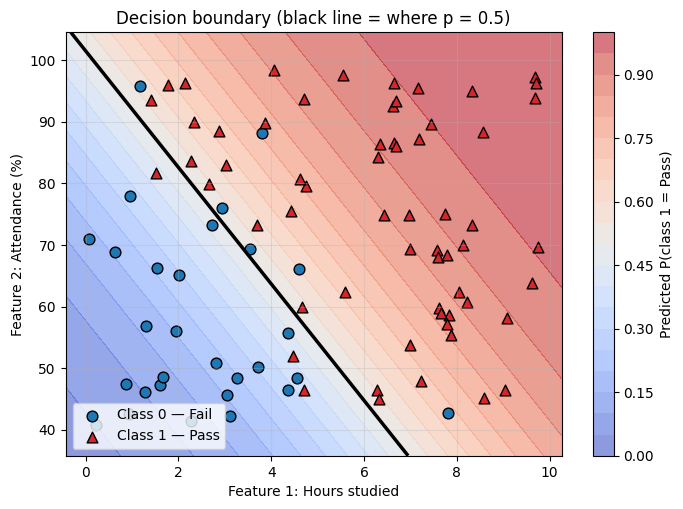

Boundary equation:  -5.098 + 0.475·hours + 0.050·attendance = 0


In [ ]:
# ---- Build a grid covering the feature space ---------------------------
x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
x2_min, x2_max = X[:, 1].min() - 5,   X[:, 1].max() + 5

xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 300),
                       np.linspace(x2_min, x2_max, 300))
grid_points = np.c_[xx1.ravel(), xx2.ravel()]

# Probability of class 1 at every point on the grid
grid_proba = model.predict_proba(grid_points)[:, 1].reshape(xx1.shape)

# ---- Plot --------------------------------------------------------------
plt.figure(figsize=(8, 5.5))
plt.contourf(xx1, xx2, grid_proba, levels=20, cmap="coolwarm", alpha=0.6)
plt.colorbar(label="Predicted P(class 1 = Pass)")

# The decision boundary is the p = 0.5 contour
plt.contour(xx1, xx2, grid_proba, levels=[0.5], colors="black", linewidths=2.5)

# Overlay the actual training points
plt.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1],
            marker="o", c="tab:blue", edgecolor="k", s=60, label="Class 0 — Fail")
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1],
            marker="^", c="tab:red", edgecolor="k", s=60, label="Class 1 — Pass")

plt.xlabel("Feature 1: Hours studied")
plt.ylabel("Feature 2: Attendance (%)")
plt.title("Decision boundary (black line = where p = 0.5)")
plt.legend(loc="lower left")
plt.show()

b0 = model.intercept_[0]
b1, b2 = model.coef_[0]
print(f"Boundary equation:  {b0:.3f} + {b1:.3f}·hours + {b2:.3f}·attendance = 0")

### Reading the decision boundary plot

* **The black line is the boundary.** Points on one side are predicted Fail, points on the other side Pass.
* **The colour gradient is the probability**, not the prediction. Deep blue means the model is confident
  it is class 0; deep red means confident class 1. Near the black line the colour is pale — the model is
  close to a coin flip there.
* **Some points sit on the "wrong" side.** Those are the model's mistakes on the training data. Given the
  overlap we saw in Section 7, that is unavoidable — and a model with *zero* training mistakes here would
  likely be overfitting.
* **Moving the threshold moves the line.** If we used 0.7 instead of 0.5, the black line would shift into
  the red region — we would demand more evidence before declaring "Pass". Hold that thought for Part F.

### 🧠 Question 10.1 — Decision boundary

> **(a)** The decision boundary is a straight line. In your own words, explain why logistic regression always produces a straight-line (linear) decision boundary in 2D. What part of the model is responsible for this?
>
> **(b)** If a new student has coordinates that place them exactly *on* the decision boundary, what would `predict_proba()` return for them? What would `predict()` return?
>
> **(c)** Suppose we added a third feature (e.g., `assignment_score`). What shape would the decision boundary take in 3D? What about with 30 features?

✍️ **Your answers:**

(a) ...
(b) ...
(c) ...

---
# PART D — A SECOND, MORE REALISTIC EXAMPLE
---

## 11. The Breast Cancer Wisconsin Dataset

This dataset ships with scikit-learn, so there is **nothing to download**.

**What it is:** measurements computed from digitised images of fine-needle aspirates of breast masses.
Each row is one tumour sample.

**The features (30 of them):** numerical descriptions of the cell nuclei visible in the image — things like
`mean radius`, `mean texture`, `mean perimeter`, `mean area`, `mean smoothness`. Roughly, ten base
measurements are each reported three ways: the *mean*, the *standard error*, and the *worst* (largest) value
found in that image. You do **not** need any medical background to work with them — treat them as 30
numeric columns describing the size, shape and texture of the cells.

**The target:** each sample is labelled **malignant** (cancerous) or **benign** (not cancerous).

**Why this is binary classification:** there are exactly two possible labels, and given a new set of
measurements we want to predict which one applies.

### ⚠️ An important setup decision: which class is "positive"?

Scikit-learn ships this dataset with `0 = malignant` and `1 = benign`. Since the clinically interesting
event is *detecting cancer*, it is clearer to make that our "positive" class (class 1). We will **flip
the encoding** so that:

* **1 = malignant** (the event we want to detect → the positive class)
* **0 = benign**

Now a **false negative means a malignant tumour was labelled benign** — the error that actually endangers a
patient. Choosing your positive class deliberately, before you evaluate anything, is part of doing
this properly. It makes the confusion matrix far easier to read.

In [ ]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

print("Feature matrix shape:", data.data.shape)
print("Number of features  :", len(data.feature_names))
print("Original target names (index 0 and 1):", data.target_names)
print("\nFirst 10 feature names:")
for name in data.feature_names[:10]:
    print("  -", name)

Feature matrix shape: (569, 30)
Number of features  : 30
Original target names (index 0 and 1): ['malignant' 'benign']

First 10 feature names:
  - mean radius
  - mean texture
  - mean perimeter
  - mean area
  - mean smoothness
  - mean compactness
  - mean concavity
  - mean concave points
  - mean symmetry
  - mean fractal dimension


## 12. Data Exploration

Before modelling: load it into a DataFrame, check the shape, look at some rows, check the class balance,
and check for missing values.

### Exploring the Breast Cancer Dataset


In [ ]:

# The `data` object is already loaded from sklearn.datasets.load_breast_cancer()

cancer_df = pd.DataFrame(data.data, columns=data.feature_names)
cancer_df["target"] = 1 - data.target

LABELS = {0: "benign", 1: "malignant"}

print("Shape (rows, columns):", cancer_df.shape)
display(cancer_df.head())

print("\nClass distribution:")
counts = cancer_df["target"].value_counts().sort_index()
for cls, count in counts.items():
    print(f"  {cls} ({LABELS[cls]:>9}): {count:3d} samples  ({count / len(cancer_df):.1%})")

total_missing = cancer_df.isnull().sum().sum()
print(f"\nTotal missing values: {total_missing}")

print("\nRanges of selected features:")
display(cancer_df[["mean radius", "mean area", "mean smoothness", "worst area"]].describe().round(3))

Shape (rows, columns): (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1



Class distribution:
  0 (   benign): 357 samples  (62.7%)
  1 (malignant): 212 samples  (37.3%)

Total missing values: 0

Ranges of selected features:


,mean radius,mean area,mean smoothness,worst area
count,569.000,569.000,569.000,569.000
mean,14.127,654.889,0.096,880.583
std,3.524,351.914,0.014,569.357
min,6.981,143.500,0.053,185.200
25%,11.700,420.300,0.086,515.300
50%,13.370,551.100,0.096,686.500
75%,15.780,782.700,0.105,1084.000
max,28.110,2501.000,0.163,4254.000


### Provided visualization (run after completing Exercise 4)

Compare your exploration with the plots below. Your `cancer_df` must be correctly built above
for this cell to run.

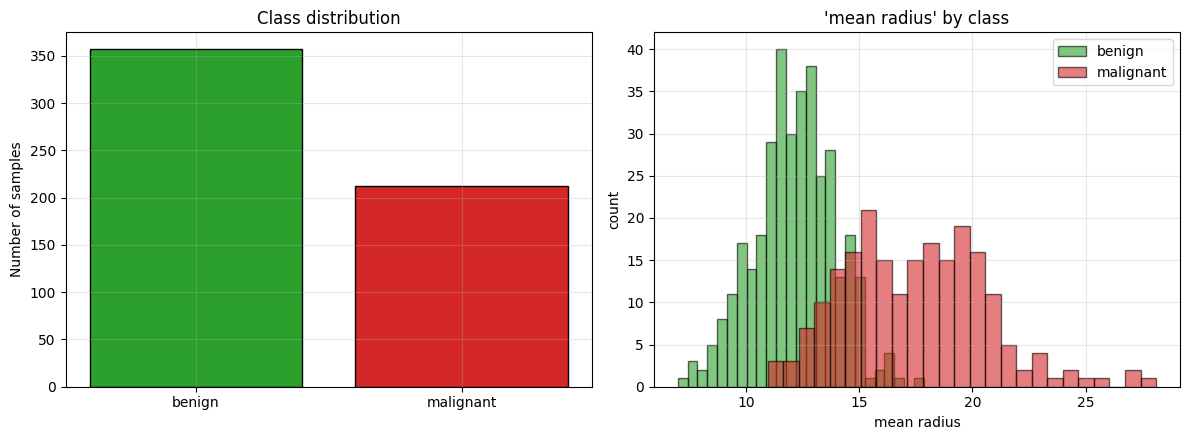

In [ ]:
# ---- Visualise the class balance and one informative feature -----------
counts = cancer_df["target"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar([LABELS[c] for c in counts.index], counts.values,
            color=["tab:green", "tab:red"], edgecolor="k")
axes[0].set_title("Class distribution")
axes[0].set_ylabel("Number of samples")

for cls, colour in [(0, "tab:green"), (1, "tab:red")]:
    subset = cancer_df[cancer_df["target"] == cls]["mean radius"]
    axes[1].hist(subset, bins=25, alpha=0.6, color=colour, label=LABELS[cls], edgecolor="k")
axes[1].set_title("'mean radius' by class")
axes[1].set_xlabel("mean radius")
axes[1].set_ylabel("count")
axes[1].legend()

plt.tight_layout()
plt.show()

### 🧠 Question 12.1

Look at the two plots and the `describe()` output above.

> **(a)** Are the classes balanced? Would a model that always predicts "benign" get a high accuracy here?
> **(b)** Does `mean radius` look useful for separating the two classes? How can you tell from the histogram?
> **(c)** Compare the ranges of `mean smoothness` and `worst area`. Roughly how many times larger is one than the other?

✍️ **Your answer:**

...

## 13. Train/Test Split, Feature Scaling, and Data Leakage

### Why scale features for logistic regression?

Look at the ranges you just printed: `mean smoothness` lives around `0.1`, while `worst area` runs into the
thousands. Two consequences:

1. **The optimiser struggles.** Logistic regression is fit by iterative optimisation (gradient-based). When
   features have wildly different scales, the optimiser zig-zags and may hit its iteration limit before
   converging — you will literally see a `ConvergenceWarning`.
2. **Coefficients become uninterpretable.** A coefficient is "change in $z$ per one unit of the feature".
   One unit of `worst area` is a trivial change; one unit of `mean smoothness` is enormous. Comparing the raw
   $\beta$ values across features would be meaningless.

**Standardisation** rescales each feature to mean 0 and standard deviation 1:

$$x_{\text{scaled}} = \frac{x - \mu}{\sigma}$$

### 🚨 Data leakage — the mistake to avoid

**Fit the scaler on the training data only.**

```python
scaler.fit(X_train)          # ✅ learn μ and σ from the training data only
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # ✅ apply the SAME μ and σ
```

```python
scaler.fit(X)                # ❌ WRONG — X includes the test set
```

**Why is the second version wrong?** The mean and standard deviation computed from the full dataset carry
information from the test samples. That information seeps into the training process, so your test score is
no longer an honest estimate of performance on *unseen* data — it is optimistically biased. This is called
**data leakage**.

The deeper principle: **the test set must be treated as if it does not exist until the moment you evaluate.**
In production this is obvious — tomorrow's patients genuinely have not been measured yet, so you *cannot*
have used their statistics to build your scaler. Any preprocessing step that *learns* something from data
(scalers, imputers, PCA, feature selection) is subject to this rule.

> **Order matters: split first, then fit the scaler.** Doing it the other way round is one of the most common
> bugs in student (and professional!) ML code — and it is invisible, because the code runs fine and the
> scores just look *better*.

### ✍️ EXERCISE 4 — Split and Scale (Without Leakage)

You just read why the order matters. Now do it yourself. **Complete the code below.**
The variables you create here (`Xc_train_scaled`, `Xc_test_scaled`, `yc_train`, `yc_test`)
are needed by every cell from here on.

In [ ]:
# ===================== EXERCISE 4 — SPLIT AND SCALE =====================
from sklearn.preprocessing import StandardScaler

X_cancer = cancer_df.drop(columns="target").values
y_cancer = cancer_df["target"].values

# TODO 1: split into training and test sets.
#         Use test_size=0.2, random_state=RANDOM_STATE, stratify=y_cancer
# Xc_train, Xc_test, yc_train, yc_test = train_test_split(...)

# TODO 2: create a StandardScaler and fit it on the TRAINING data ONLY.
#         Write a comment explaining why you must not fit on the full data.
# scaler = StandardScaler()
# scaler.fit(...)

# TODO 3: transform BOTH training and test data using the SAME fitted scaler.
# Xc_train_scaled = scaler.transform(...)
# Xc_test_scaled  = scaler.transform(...)

# TODO 4: verify your work — print the mean/std of each set.
#         Training should be ~0 mean, ~1 std. Test should be close but NOT exact.
# print(f"Training samples: {Xc_train.shape[0]}   Test samples: {Xc_test.shape[0]}")
# print("  train mean:", round(float(Xc_train_scaled.mean()), 6),
#       " train std:", round(float(Xc_train_scaled.std()), 6))
# print("  test  mean:", round(float(Xc_test_scaled.mean()), 6),
#       " test  std:", round(float(Xc_test_scaled.std()), 6))

That last output is the point of the whole section: the **test** set does not come out perfectly centred,
because we deliberately did **not** let the scaler look at it. If your test set came out at exactly mean 0
and std 1, that would be a symptom of leakage.

### 🧠 Question 13.1 — Scaling and data leakage

> **(a)** Look at the printed train and test means above. The training mean is almost exactly 0, but the test mean is not. Explain in your own words why this is the correct and expected behavior.
>
> **(b)** A classmate runs the following code and gets test accuracy of 98%. They proudly report this number. What is wrong with their approach?
> ```python
> scaler = StandardScaler()
> X_scaled = scaler.fit_transform(X)
> X_train, X_test, y_train, y_test = train_test_split(X_scaled, y)
> model.fit(X_train, y_train)
> print("Test accuracy:", model.score(X_test, y_test))
> ```
>
> **(c)** Would the same leakage concern apply if we used MinMaxScaler instead of StandardScaler? What about if we simply divided every feature by 1000 (a fixed constant, not learned from data)?

✍️ **Your answers:**

(a) ...
(b) ...
(c) ...

## 14. Training the Model

`max_iter=1000` raises the optimiser's iteration budget. The default (100) is sometimes not enough for
30 features, and scikit-learn would warn that the fit did not converge.

### ✍️ EXERCISE 5 — Train and Evaluate the Model

Now put it all together: train a logistic regression on the scaled data and check how it does.
**Complete the code below.** The variable `cancer_model` is needed by all subsequent cells.

In [ ]:
# ===================== EXERCISE 5 — TRAIN AND EVALUATE =====================
from sklearn.linear_model import LogisticRegression

# TODO 1: create a LogisticRegression with max_iter=1000 and random_state=RANDOM_STATE
# cancer_model = LogisticRegression(...)

# TODO 2: fit the model on the SCALED training data
# cancer_model.fit(...)

# TODO 3: compute and print training accuracy and test accuracy.
#         Hint: model.score(X, y) returns accuracy.
# train_acc = cancer_model.score(...)
# test_acc  = cancer_model.score(...)
# print(f"Training accuracy: {train_acc:.4f}")
# print(f"Test accuracy    : {test_acc:.4f}")
# print(f"Gap (train − test): {train_acc - test_acc:.4f}")

In [ ]:
# Predictions and probabilities on the test set
yc_pred  = cancer_model.predict(Xc_test_scaled)
yc_proba = cancer_model.predict_proba(Xc_test_scaled)[:, 1]   # P(malignant)

results = pd.DataFrame({
    "P(malignant)": yc_proba.round(4),
    "predicted":    yc_pred,
    "actual":       yc_test
})
results["correct"] = results["predicted"] == results["actual"]

print("First 10 test predictions:")
display(results.head(10))

print("\nThe 5 predictions the model was LEAST sure about (probability closest to 0.5):")
display(results.iloc[(results["P(malignant)"] - 0.5).abs().argsort()[:5]])

NameError: name 'cancer_model' is not defined

The train and test accuracies are close, which suggests the model is **not badly overfitting**. A large gap
(say, 100% train vs 85% test) would be a warning sign that the model memorised the training set.

Notice the second table: the samples the model is least sure about are exactly where you would expect
mistakes to cluster. Probabilities give you information that a bare 0/1 prediction throws away.

### 🧠 Question 14.1 — Training vs testing

> **(a)** The gap between training and test accuracy is small. Why is this a good sign?
>
> **(b)** If training accuracy were 100% but test accuracy were 75%, what would that suggest about the model?
>
> **(c)** The second table shows the 5 predictions the model was least confident about. Why are these cases interesting from a clinical perspective? What might a doctor do differently for these patients compared to ones the model is very confident about?

✍️ **Your answers:**

(a) ...
(b) ...
(c) ...

## 15. Evaluating the Model



### 15.1 Start with the confusion matrix

Every prediction a binary classifier makes falls into exactly one of four buckets. Suppose we build a
**medical screening test** where **class 1 = "disease present"**:

|  | **Predicted 0** (no disease) | **Predicted 1** (disease) |
|---|---|---|
| **Actual 0** (no disease) | **TN** — True Negative ✅ correctly cleared | **FP** — False Positive ❌ *false alarm* |
| **Actual 1** (disease) | **FN** — False Negative ❌ *missed case* | **TP** — True Positive ✅ correctly caught |

Memory aid: the **second word** is what the model *predicted*; the **first word** says whether it was *right*.
"False Negative" = the model said negative, and it was wrong.

**The two error types are not equally bad, and which one hurts more depends entirely on the problem:**

* **Medical screening** — a **FN** means a sick patient is sent home untreated. A **FP** means an anxious
  patient gets a second test. FN is far worse.
* **Spam filtering** — a **FP** means an important email from your professor lands in the spam folder,
  possibly never seen. A **FN** means one junk email reaches your inbox. Here **FP** is worse.

There is no universal answer. *You* have to decide which mistake your application can least afford.

### 15.2 A concrete example

100 people are screened. 10 actually have the disease.

|  | Predicted: no disease | Predicted: disease |
|---|---|---|
| **Actually no disease (90)** | TN = 85 | FP = 5 |
| **Actually has disease (10)** | FN = 3 | TP = 7 |

We will use these numbers (TP=7, TN=85, FP=5, FN=3) throughout the next four definitions.

### Confusion Matrix and Interpretation


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

yc_pred = cancer_model.predict(Xc_test_scaled)

cm_cancer = confusion_matrix(yc_test, yc_pred)

tn_c, fp_c, fn_c, tp_c = cm_cancer.ravel()

print(f"Accuracy: {accuracy_score(yc_test, yc_pred):.4f}")
print()
print("Confusion matrix breakdown:")
print(f"  TN = {tn_c}  (benign, correctly identified)")
print(f"  FP = {fp_c}  (benign tumour flagged as malignant  → unnecessary follow-up)")
print(f"  FN = {fn_c}  (malignant tumour MISSED             → DANGEROUS)")
print(f"  TP = {tp_c}  (malignant, correctly detected)")

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_cancer,
    display_labels=["benign (0)", "malignant (1)"]
)
disp.plot()
plt.title("Breast Cancer — Test Set")
plt.show()


🧠 Question 15.1 — Interpret the results

Answer these using the numbers your run produced (do not just repeat the definitions):

> **(a)** What is the test accuracy? A model that always predicts "benign" would get roughly 63% accuracy
> (since ~63% of samples are benign). How much better than this baseline is our model?
>
> **(b)** How many malignant tumours did the model miss (FN)? In a real screening programme, what would
> be the consequence of each one?
>
> **(c)** How many benign tumours were incorrectly flagged as malignant (FP)? What is the real-world cost
> of each false positive compared to a false negative?
>
> **(d)** Suppose a hospital told you "we would rather re-test 20 healthy people than miss 1 cancer."
> Which of the four confusion-matrix cells (TP, TN, FP, FN) are they saying they want to minimise, and
> which are they willing to tolerate more of?

✍️ **Your answers:**

(a) ...
(b) ...
(c) ...
(d) ...


---
# PART F — THE CLASSIFICATION THRESHOLD
---

## 16. Moving the Threshold

Here is the key realisation of this lab:

> **The model outputs a probability. The threshold that turns it into a decision is a *separate choice*,
> and 0.5 is nothing more than a default.**

`model.predict()` hard-codes 0.5. But nothing stops us from applying our own:

```python
probabilities = model.predict_proba(X_test)[:, 1]
predictions   = (probabilities >= 0.3).astype(int)
```

Lowering the threshold means we need **less evidence** to call something positive, so we flag **more**
cases → we catch more true positives but also raise more false alarms.

Raising the threshold means we demand **stronger evidence**, so we flag **fewer** cases → fewer false
alarms, but we also miss more true positives.

Let's see this concretely by trying three thresholds and looking at the confusion matrix for each.


### ✍️ EXERCISE 6 — Explore the Classification Threshold

Instead of running pre-written threshold code, write it yourself. Use the probabilities from
`cancer_model` and try multiple thresholds. **Complete the code below.**

In [ ]:
# ===================== EXERCISE 6 — THRESHOLD EXPERIMENTS =====================

# TODO 1: get the predicted probabilities of the POSITIVE class (malignant)
#         for the test set.
probabilities = cancer_model.predict_proba(Xc_test_scaled)[:, 1]

# TODO 2: for each threshold in [0.2, 0.3, 0.5, 0.7, 0.8]:
#         - convert probabilities to 0/1 predictions using that threshold
#         - compute confusion matrix and unpack tn, fp, fn, tp
#         - compute accuracy
#         - print a summary for each threshold
for t in [0.2, 0.3, 0.5, 0.7, 0.8]:
    preds = (probabilities >= t).astype(int)
    cm_t = confusion_matrix(yc_test, preds)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    print(f"--- Threshold = {t} ---")
    print(f"  TP = {tp_t}  FP = {fp_t}  FN = {fn_t}  TN = {tn_t}")
    print(f"  Accuracy = {accuracy_score(yc_test, preds):.3f}")
    print()

### The trade-off, stated precisely

| | Positive predictions | Cancers caught (TP) | False alarms (FP) | Cancers missed (FN) |
|---|---|---|---|---|
| **Lower threshold** (e.g. 0.3) | more | more ✅ | more ❌ | fewer |
| **Higher threshold** (e.g. 0.7) | fewer | fewer | fewer ✅ | more ❌ |

### Choosing a threshold is a *business* decision, not a mathematical one

There is no formula that outputs "the right threshold". It depends on the **relative cost of the two
error types** in your specific application:

* **Cancer screening** → a missed malignancy (FN) is catastrophic, a false alarm (FP) means one more test.
  Push the threshold **down** (e.g. 0.2–0.3) so you catch as many cancers as possible.
* **Spam filtering** → losing a real email (FP) is worse than seeing one spam (FN).
  Push the threshold **up**.
* **Loan approval, fraud blocking, content moderation** → each has its own answer, and it usually comes
  from people outside the ML team.

⚠️ One methodological caution: if you tune the threshold by staring at test-set scores, you are letting
the test set influence your choices — a mild form of leakage. In practice you would tune it on a separate
**validation** set and only then report the test result.


### 🧠 Question 16.1 — Threshold in practice

> **(a)** Compare the three thresholds above. At threshold 0.3, how many cancers are missed (FN)?
> At threshold 0.7? What is the cost of raising the threshold, in concrete terms?
>
> **(b)** A hospital administrator says: "Just set the threshold to 0.1 to catch every cancer case."
> What would be the practical consequence of this for the hospital's workflow? (Think about how many
> total patients would be flagged.)
>
> **(c)** Explain why `model.predict()` always uses 0.5 as the threshold. If you wanted to deploy
> your model with a threshold of 0.3, how would you generate predictions in your code? Write the
> one-line Python expression.

✍️ **Your answers:**

(a) ...
(b) ...
(c) ...


---
# PART G —  EXERCISES
---

You have now built all the core skills through the inline exercises above. The remaining
exercises ask you to apply everything to **new data**, with less scaffolding.

**Rules of engagement**

* Do not delete the `TODO` comments — replace the placeholder lines beneath them with working code.
* Every exercise has written questions. **Answer them in the ✍️ cells.** A correct number with no
  interpretation earns partial credit at best.
* You may re-use any code from the exercises above.

---

## Exercise 7 — Train Your Own Logistic Regression Model

Below is a fresh synthetic dataset: predicting whether a customer **buys a product** (`1`) or **does not**
(`0`), based on their **age** and **annual income**.

Run the setup cell (it is complete), then finish the modelling cell.

In [ ]:
# ===================== EXERCISE 7 — SETUP (already complete, just run it) ====
import numpy as np
import pandas as pd

rng2 = np.random.default_rng(7)
m = 200

age    = rng2.integers(18, 70, m)
income = rng2.normal(50000, 18000, m).clip(15000, 120000).round(-2)

z_true  = -6.0 + 0.06 * age + 0.00007 * income
p_true  = 1 / (1 + np.exp(-z_true))
bought  = rng2.binomial(1, p_true)

customers = pd.DataFrame({"age": age, "income": income, "bought": bought})

print("Shape:", customers.shape)
print("Class distribution:\n", customers["bought"].value_counts().sort_index())
customers.head()

In [ ]:
# ===================== EXERCISE 7 — YOUR WORK =====================
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# TODO 1: build the feature matrix X2 (age and income) and the label vector y2
# X2 = customers[[...]].values
# y2 = customers[...].values

# TODO 2: split into training and test sets.
#         Use test_size=0.25, random_state=42, and stratify on the labels.
# X2_train, X2_test, y2_train, y2_test = train_test_split(...)

# TODO 3: create a LogisticRegression model and fit it on the TRAINING data ONLY
# model2 = ...
# model2.fit(...)

# TODO 4: predict the labels for the test set
# y2_pred = ...

# TODO 5: compute and print the test accuracy (rounded to 3 decimals)
# print("Test accuracy:", ...)

# TODO 6: print the learned intercept and coefficients.
#         Then answer: which feature has the larger coefficient?
# print("Intercept:", ...)
# print("Coefficients:", ...)

### Questions

> **1.** What test accuracy did you get? Compare it to the accuracy of a "dumb" baseline that always
> predicts the majority class. (Compute that baseline — it is just the fraction of the majority class in the
> test set.) Is your model actually adding value?
> **2.** Which feature received the larger coefficient? Is it fair to conclude that feature is more
> important? Look at the *scale* of `age` versus `income` before answering.
> **3.** Try re-running your split with `random_state=1` and then `random_state=99`. Does the accuracy
> change? What does that tell you about reporting a single accuracy number?

✍️ **Your answers:**

1. ...
2. ...
3. ...

## Exercise 8 — Feature Analysis

Which measurements does the model actually rely on to decide "malignant"?

Because we **standardised** the features in Part E, all 30 are now on a comparable scale — which is exactly
what makes comparing coefficient magnitudes legitimate here. (If we had skipped scaling, this exercise would
be meaningless. Make sure you understand why.)

In [ ]:
# ===================== EXERCISE 8 — YOUR WORK =====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# TODO 1: extract the coefficients from cancer_model.
#         Careful: model.coef_ has shape (1, 30) — you want a flat array of 30 numbers.
# coefs = ...

# TODO 2: get the 30 feature names (available as data.feature_names)
# names = ...

# TODO 3: build a DataFrame with columns: "feature", "coefficient", "abs_coefficient"
# coef_df = pd.DataFrame({...})

# TODO 4: sort by absolute coefficient magnitude, largest first, and show the top 10
# top10 = ...
# display(top10)

# TODO 5: draw a horizontal bar chart of the top 10 (plt.barh).
#         Colour bars by the SIGN of the coefficient so positive and negative are
#         visually distinct, and add a legend or annotation explaining the colours.

# TODO 6: print the 3 features with the SMALLEST absolute coefficients.

### Questions

> **1.** List your top 5 features. Do they seem to describe size, shape, or texture of the cells?
> Is there a pattern?
> **2.** What does a **positive** coefficient mean here, given that class 1 = malignant? What does a
> **negative** one mean? Answer in terms of the linear score $z$ and the sigmoid.
> **3.** Several of the 30 features are closely related (e.g. `mean radius`, `mean perimeter` and
> `mean area` all grow together). What problem might that cause when you try to read individual
> coefficients as "importance"? What would happen to the coefficients if you deleted one of them?
> **4.** Why would this entire analysis have been invalid if we had **not** scaled the features first?
> **5.** The features with the smallest coefficients — does a near-zero coefficient prove the feature is
> useless? Give one reason to be cautious.

✍️ **Your answers:**

1. ...
2. ...
3. ...
4. ...
5. ...

## Exercise 9 — Challenge Problem: The Complete Pipeline

**This is the main assessed exercise.** You are given a dataset you have not seen before. Build the entire
binary classification workflow yourself, from raw data to written conclusion.

### The scenario

A telecom company wants to predict **customer churn** — whether a customer will cancel their subscription
(`1 = churn`, `0 = stays`). You have 6 features per customer:

| Feature | Meaning |
|---|---|
| `tenure_months` | how long they have been a customer |
| `monthly_charges` | monthly bill amount |
| `support_calls` | number of support calls in the last year |
| `data_usage_gb` | average monthly data usage |
| `contract_length` | contract length in months (1, 12 or 24) |
| `age` | customer age |

Run the cell below to generate the data. **Do not modify it.**

In [ ]:
# ===================== EXERCISE 9 — DATA (run this, do not modify) ==========
import numpy as np
import pandas as pd

rng6 = np.random.default_rng(2024)
N = 900

tenure_months   = rng6.integers(1, 72, N)
monthly_charges = rng6.normal(70, 25, N).clip(20, 150).round(2)
support_calls   = rng6.poisson(2.0, N)
data_usage_gb   = rng6.gamma(shape=2.5, scale=8, size=N).clip(0.5, 100).round(1)
contract_length = rng6.choice([1, 12, 24], size=N, p=[0.45, 0.35, 0.20])
age             = rng6.integers(18, 80, N)

z6 = (-0.9
      - 0.045 * tenure_months
      + 0.020 * monthly_charges
      + 0.42  * support_calls
      - 0.010 * data_usage_gb
      - 0.075 * contract_length
      - 0.008 * age)
p6 = 1 / (1 + np.exp(-z6))
churn = rng6.binomial(1, p6)

churn_df = pd.DataFrame({
    "tenure_months":   tenure_months,
    "monthly_charges": monthly_charges,
    "support_calls":   support_calls,
    "data_usage_gb":   data_usage_gb,
    "contract_length": contract_length,
    "age":             age,
    "churn":           churn
})

print("Dataset ready. Shape:", churn_df.shape)
churn_df.head()

### Your tasks

Work through these **in order**, using a separate code cell for each stage where it helps (add cells with
the `+ Code` button in Colab). Write a short Markdown note after each stage explaining what you found.

1. **Load the data** into `X` and `y`.
2. **Explore** — shape, `head()`, `describe()`, class distribution, missing values.
3. **Visualise** — at least two informative plots. Suggestions: the class balance; a histogram of one
   feature split by class; a scatter plot of two features coloured by class.
4. **Split** into train and test sets (use `random_state=42` and `stratify=y`).
5. **Scale** the features. Fit the scaler on the training set **only** — state in a comment why.
6. **Train** a logistic regression model.
7. **Predict** class labels for the test set.
8. **Predict probabilities** for the test set.
9. **Evaluate** with accuracy and the confusion matrix.
10. **Analyse the confusion matrix** — plot it and state what each of the four cells means *in business terms*
    (e.g. "FP = a loyal customer we wasted a retention discount on").
11. **Experiment with thresholds** — try at least four, tabulate TP, FP, FN, TN and accuracy for each, and pick one you would deploy.
12. **Write a conclusion** (roughly 150–250 words) covering: how well the model performs, which error
    type (FP or FN) matters more *for this business problem* and why, which threshold you recommend,
    which features appear most influential, and one concrete limitation of your analysis.

In [ ]:
# ===================== EXERCISE 9 — YOUR PIPELINE STARTS HERE ==============
# Add as many code cells as you need below this one.

# --- Stage 1: Load ---------------------------------------------------------
# TODO: create X (all six feature columns) and y (the churn column)


# --- Stage 2: Explore ------------------------------------------------------
# TODO


# --- Stage 3: Visualise ----------------------------------------------------
# TODO


# --- Stage 4: Train/test split ---------------------------------------------
# TODO


# --- Stage 5: Scale (fit on training data ONLY) ----------------------------
# TODO


# --- Stage 6: Train --------------------------------------------------------
# TODO


# --- Stage 7 & 8: Predictions and probabilities ----------------------------
# TODO


# --- Stage 9: Metrics ------------------------------------------------------
# TODO


# --- Stage 10: Confusion matrix --------------------------------------------
# TODO


# --- Stage 11: Threshold experiments ---------------------------------------
# TODO

✍️ **Your conclusion (150–250 words):**

...

---

### Hints (read only if you are stuck)

* Your accuracy will likely land somewhere in the 70s or low 80s. That is **normal** — this data is
  deliberately noisy, and a mediocre score honestly reported beats a suspiciously perfect one.
* Check the class balance early. If churn is a minority class, accuracy will flatter your model.
* `contract_length` only takes three values. It is still fine to feed into logistic regression as a number,
  but think about whether treating "1, 12, 24" as a continuous scale is really what you want — mention this
  in your limitations.
* If you get a `ConvergenceWarning`, check that you scaled the features and raise `max_iter`.

---
# 17. Key Takeaways
---

| # | Idea | One-line summary |
|---|---|---|
| 1 | Classification vs regression | Regression predicts a number; classification predicts a category. |
| 2 | Why not a straight line | Linear regression's output escapes [0, 1] and cannot be read as a probability. |
| 3 | Sigmoid | $\sigma(z) = 1/(1+e^{-z})$ squashes any real number into $(0,1)$. |
| 4 | Logistic regression | Linear score → sigmoid → probability → threshold → class label. |
| 5 | The name | It is *called* regression because it fits a linear model to the log-odds; it is *used* for classification. |
| 6 | Three distinct things | The score $z$, the probability $p$, and the label $\hat{y}$ are not interchangeable. |
| 7 | Decision boundary | The set of points where $p = 0.5$, i.e. $z = 0$ — a straight line. |
| 8 | Confusion matrix | Four cells: TP, TN, FP, FN. Always look at it before trusting a single number. |
| 9 | Accuracy | Useful summary, but can be misleading when classes are imbalanced. |
| 10 | Error types matter | FP and FN have different real-world costs; which one to minimise depends on your application. |
| 11 | Threshold | 0.5 is a default, not a law. Lower it to catch more positives; raise it to reduce false alarms. |
| 12 | Scaling | Helps convergence and makes coefficients comparable. |
| 13 | Data leakage | Split first, then fit the scaler on the training set only — never on the full data. |

### Where to go next

Once you are comfortable with everything above, the natural next steps are **precision, recall, and
F1-score** (metrics that formalise the TP/FP/FN trade-offs you explored here), the **ROC curve and AUC**
(a threshold-free way to summarise a classifier), **multiclass logistic regression** (softmax), and
**cross-validation** for more reliable performance estimates.

---

*End of lab.*
